# LC0-Style Chess Neural Network

**Architecture**: Deep Residual CNN with Policy + Value heads (AlphaZero / Leela Chess Zero style)  
**Training**: Supervised learning from Stockfish evaluations  
**Input**: AlphaZero-style board encoding (17 planes, 8×8)  
**Action Space**: ~4672 moves (AlphaZero encoding)  

---

## 1. Install Dependencies

In [1]:
!pip install -q python-chess torch torchvision numpy
!apt-get install -q -y stockfish 2>/dev/null || pip install stockfish -q
print('Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 125.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Reading package lists...
Building dependency tree...
Reading state information...
Suggested packages:
  polyglot xboard | scid
The following NEW packages will be installed:
  stockfish
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 24.8 MB of archives.
After this operation, 47.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 stockfish amd64 14.1-1 [24.8 MB]
Fetched 24.8 MB in 0s (86.3 MB/s)
Selecting previously unselected package stockfish.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../stockfish_14.1-1_amd64.deb ...
Unpacking stockfish (14.1-1) ...
Setting up stockfish (14.1-1) ...
Processing triggers for man-db (2.10.2-1) ...
Dependencies installed.


## 2. Configuration

In [2]:
import os

# ============================================================
# CONFIGURATION — Edit these before running
# ============================================================

QUICK_TEST_MODE = False          # True → tiny model for fast smoke-test

# Model architecture
NUM_RESIDUAL_BLOCKS = 6 if QUICK_TEST_MODE else 15
NUM_CHANNELS        = 32 if QUICK_TEST_MODE else 128
INPUT_PLANES        = 17         # board encoding depth

# Training
BATCH_SIZE          = 32  if QUICK_TEST_MODE else 256
LEARNING_RATE       = 1e-3
WEIGHT_DECAY        = 1e-4
GRAD_CLIP           = 1.0
NUM_EPOCHS          = 1000
POSITIONS_PER_EPOCH = 4000 if QUICK_TEST_MODE else 4000

# Stockfish
STOCKFISH_DEPTH     = 5 if QUICK_TEST_MODE else 8
SF_TEMPERATURE      = 1.0        # softmax temperature for policy targets
SF_VALUE_SCALE      = 400.0      # centipawns → tanh scaling
SF_MATE_SCORE       = 10000      # centipawns cap for mate

# Checkpointing
USE_DRIVE           = True       # ENABLED: Saves to Google Drive
if USE_DRIVE:
    CHECKPOINT_DIR = '/content/drive/MyDrive/chess_nn_checkpoints'
else:
    CHECKPOINT_DIR = '/content/chess_nn_checkpoints'
SAVE_EVERY_N_EPOCHS = 1

# Evaluation
EVAL_GAMES_VS_RANDOM  = 10
EVAL_GAMES_VS_SF      = 5
SF_EVAL_SKILL_LEVEL   = 0        # Stockfish skill 0–20

print(f'Config loaded. Drive Storage={USE_DRIVE}, Blocks={NUM_RESIDUAL_BLOCKS}, Channels={NUM_CHANNELS}')
print(f'  Checkpoint dir: {CHECKPOINT_DIR}')

Config loaded. Drive Storage=True, Blocks=15, Channels=128
  Checkpoint dir: /content/drive/MyDrive/chess_nn_checkpoints


## 3. Imports & Device Setup

In [3]:
import math
import time
import random
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import chess
import chess.pgn
import chess.engine

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


## 4. Google Drive Mount (Optional)

In [4]:
if USE_DRIVE:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f'Drive mounted. Checkpoints → {CHECKPOINT_DIR}')
else:
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f'Drive not mounted. Checkpoints saved locally at {CHECKPOINT_DIR}')

Mounting Google Drive...
Mounted at /content/drive
Drive mounted. Checkpoints → /content/drive/MyDrive/chess_nn_checkpoints


In [5]:
"""
  THIS CELL DELETES ALL CHECKPOINTS
  DO NOT AUTO RUN
  IT'S FOR CLEANING THE DRIVE
"""









import os

# Define the file to keep
FILE_TO_KEEP = 'lc0_epoch444_20260501_002535.pt'

print(f'Scanning directory: {CHECKPOINT_DIR}')

deleted_count = 0
for root, _, files in os.walk(CHECKPOINT_DIR):
    for file in files:
        if file == FILE_TO_KEEP:
            print(f'  Skipping protected file: {file}')
            continue
        if file.endswith('.pt') or file.endswith('.pgn'):
            file_path = os.path.join(root, file)
            try:
                os.remove(file_path)
                print(f'  Deleted: {file_path}')
                deleted_count += 1
            except Exception as e:
                print(f'  Error deleting {file_path}: {e}')

print(f'Finished cleanup. Total files deleted: {deleted_count}')

Scanning directory: /content/drive/MyDrive/chess_nn_checkpoints
  Skipping protected file: lc0_epoch444_20260501_002535.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/lc0_epoch445_20260502_153035.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/lc0_epoch446_20260502_155024.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/lc0_epoch447_20260502_161012.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/lc0_epoch448_20260502_163012.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/lc0_epoch449_20260502_165016.pt
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/eval_games/epoch445_vs_stockfish_skill0_game00.pgn
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/eval_games/epoch446_vs_stockfish_skill0_game00.pgn
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/eval_games/epoch447_vs_stockfish_skill0_game00.pgn
  Deleted: /content/drive/MyDrive/chess_nn_checkpoints/eval_games/epoch448_vs_stockfish_skill0_game00.pgn
  Deleted: /conten

## 5. Board Encoding — AlphaZero Style (17 Planes)

In [6]:
"""
Input representation (17 planes, 8×8):
  Planes 0-5   : White pieces (P, N, B, R, Q, K)
  Planes 6-11  : Black pieces (P, N, B, R, Q, K)
  Plane  12    : Side to move (1 = white, 0 = black — filled)
  Planes 13-16 : Castling rights (WK, WQ, BK, BQ)
"""

PIECE_TYPES = [chess.PAWN, chess.KNIGHT, chess.BISHOP,
               chess.ROOK, chess.QUEEN, chess.KING]

def board_to_tensor(board: chess.Board) -> torch.Tensor:
    """Encode a chess.Board into a (17, 8, 8) float32 tensor."""
    planes = np.zeros((17, 8, 8), dtype=np.float32)

    # Piece planes
    for color_idx, color in enumerate([chess.WHITE, chess.BLACK]):
        for pt_idx, pt in enumerate(PIECE_TYPES):
            plane_idx = color_idx * 6 + pt_idx
            for sq in board.pieces(pt, color):
                rank, file = divmod(sq, 8)
                planes[plane_idx, rank, file] = 1.0

    # Side to move
    if board.turn == chess.WHITE:
        planes[12, :, :] = 1.0

    # Castling rights
    if board.has_kingside_castling_rights(chess.WHITE):  planes[13, :, :] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE): planes[14, :, :] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK):  planes[15, :, :] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK): planes[16, :, :] = 1.0

    return torch.tensor(planes, dtype=torch.float32)


# Quick sanity check
board = chess.Board()
t = board_to_tensor(board)
assert t.shape == (17, 8, 8), f'Bad shape: {t.shape}'
print(f'board_to_tensor → shape {t.shape}  dtype {t.dtype}  OK')

board_to_tensor → shape torch.Size([17, 8, 8])  dtype torch.float32  OK


## 6. Action Space — AlphaZero Encoding (~4672 moves)

In [7]:
"""
AlphaZero action space (4672 indices):

Each move is encoded as (from_square, move_type_index).
  - 64 from-squares
  - 73 move-type planes:
      0-55  : Queen moves  (8 directions × 7 distances)
      56-63 : Knight moves (8 knight offsets)
      64-72 : Underpromotions (3 pieces × 3 directions: left, straight, right)
              Queen promotion is captured by the corresponding queen-move plane.

Total: 64 × 73 = 4672 indices.
"""

NUM_PLANES  = 73
ACTION_SIZE = 64 * NUM_PLANES  # 4672

# 8 queen directions: N, NE, E, SE, S, SW, W, NW
_QUEEN_DIRS = [
    (1,  0), (1,  1), (0,  1), (-1,  1),
    (-1, 0), (-1, -1), (0, -1), (1, -1)
]
# 8 knight offsets
_KNIGHT_OFFSETS = [
    (2,  1), (2, -1), (-2,  1), (-2, -1),
    (1,  2), (1, -2), (-1,  2), (-1, -2)
]
# Under-promotion pieces: knight, bishop, rook  (queen is default → queen-move plane)
_UNDERPROMO_PIECES = [chess.KNIGHT, chess.BISHOP, chess.ROOK]
# Under-promotion directions relative to forward: file offsets -1, 0, +1
_UNDERPROMO_FILE_OFFSETS = [-1, 0, 1]


def _sq(rank: int, file: int) -> int:
    return rank * 8 + file


def _move_to_plane(move: chess.Move, board: chess.Board) -> int:
    """Return the plane index (0-72) for a legal move."""
    from_sq = move.from_square
    to_sq   = move.to_square
    fr, ff  = divmod(from_sq, 8)
    tr, tf  = divmod(to_sq, 8)
    dr, df  = tr - fr, tf - ff

    # Under-promotion (not to queen)
    if move.promotion and move.promotion != chess.QUEEN:
        piece_idx = _UNDERPROMO_PIECES.index(move.promotion)  # 0, 1, 2
        dir_idx   = _UNDERPROMO_FILE_OFFSETS.index(df)        # 0, 1, 2
        return 64 + piece_idx * 3 + dir_idx

    # Knight moves
    if board.piece_type_at(from_sq) == chess.KNIGHT:
        offset = (dr, df)
        if offset in _KNIGHT_OFFSETS:
            return 56 + _KNIGHT_OFFSETS.index(offset)

    # Queen / sliding moves (including queen-promotion)
    for dir_idx, (ddr, ddf) in enumerate(_QUEEN_DIRS):
        if ddr == 0 and ddf == 0:
            continue
        if ddf != 0 and ddr != 0:
            if ddr / ddf != (dr / ddf if ddf != 0 else float('inf')):
                pass
        # Check if (dr, df) is a positive multiple of (ddr, ddf)
        if ddr == 0:
            if dr != 0: continue
            if ddf == 0: continue
            dist = df // ddf
            if ddf * dist == df and dist > 0:
                return dir_idx * 7 + (dist - 1)
        elif ddf == 0:
            if df != 0: continue
            dist = dr // ddr
            if ddr * dist == dr and dist > 0:
                return dir_idx * 7 + (dist - 1)
        else:
            if df == 0: continue
            dist_r = dr / ddr
            dist_f = df / ddf
            if abs(dist_r - dist_f) < 1e-9 and dist_r > 0 and dist_r == int(dist_r):
                return dir_idx * 7 + (int(dist_r) - 1)

    raise ValueError(f'Cannot encode move {move} on board')


def move_to_index(move: chess.Move, board: chess.Board) -> int:
    """Encode a chess.Move → integer index in [0, ACTION_SIZE)."""
    plane = _move_to_plane(move, board)
    return move.from_square * NUM_PLANES + plane


def legal_move_mask(board: chess.Board) -> torch.Tensor:
    """Return a boolean tensor of shape (ACTION_SIZE,) with True at legal move indices."""
    mask = torch.zeros(ACTION_SIZE, dtype=torch.bool)
    for move in board.legal_moves:
        try:
            idx = move_to_index(move, board)
            mask[idx] = True
        except (ValueError, IndexError):
            pass  # rare edge cases — skip
    return mask


# Verify encoding on starting position
board = chess.Board()
moves = list(board.legal_moves)
idxs  = set()
for m in moves:
    try:
        idxs.add(move_to_index(m, board))
    except ValueError:
        print(f'  WARNING: could not encode {m}')
print(f'Starting position: {len(moves)} legal moves, {len(idxs)} unique indices — OK')
print(f'ACTION_SIZE = {ACTION_SIZE}')

Starting position: 20 legal moves, 20 unique indices — OK
ACTION_SIZE = 4672


## 7. Neural Network — LC0-Style Residual CNN

In [8]:
class ResidualBlock(nn.Module):
    """Standard residual block: Conv→BN→ReLU→Conv→BN + skip→ReLU."""

    def __init__(self, channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self._init_weights()

    def _init_weights(self):
        for conv in [self.conv1, self.conv2]:
            nn.init.kaiming_normal_(conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + residual, inplace=True)


class PolicyHead(nn.Module):
    """Policy head: 1×1 conv → flatten → FC → logits over ACTION_SIZE."""

    def __init__(self, in_channels: int, action_size: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 32, kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(32)
        self.fc   = nn.Linear(32 * 8 * 8, action_size)
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.bn(self.conv(x)), inplace=True)
        x = x.view(x.size(0), -1)
        return self.fc(x)   # raw logits, shape (B, ACTION_SIZE)


class ValueHead(nn.Module):
    """Value head: 1×1 conv → flatten → FC → ReLU → FC → tanh."""

    def __init__(self, in_channels: int, hidden_size: int = 256):
        super().__init__()
        self.conv  = nn.Conv2d(in_channels, 1, kernel_size=1, bias=False)
        self.bn    = nn.BatchNorm2d(1)
        self.fc1   = nn.Linear(8 * 8, hidden_size)
        self.fc2   = nn.Linear(hidden_size, 1)
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.bn(self.conv(x)), inplace=True)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x), inplace=True)
        return torch.tanh(self.fc2(x)).squeeze(-1)  # shape (B,)


class LC0Net(nn.Module):
    """
    LC0 / AlphaZero-style residual chess network.

    Input  : (B, INPUT_PLANES, 8, 8)
    Outputs:
      policy_logits : (B, ACTION_SIZE)  — raw logits (mask + log_softmax externally)
      value         : (B,)              — scalar in (-1, 1)
    """

    def __init__(self,
                 input_planes: int  = INPUT_PLANES,
                 channels: int      = NUM_CHANNELS,
                 num_blocks: int    = NUM_RESIDUAL_BLOCKS,
                 action_size: int   = ACTION_SIZE):
        super().__init__()

        # Initial convolution
        self.initial_conv = nn.Conv2d(input_planes, channels,
                                      kernel_size=3, padding=1, bias=False)
        self.initial_bn   = nn.BatchNorm2d(channels)
        nn.init.kaiming_normal_(self.initial_conv.weight,
                                mode='fan_out', nonlinearity='relu')

        # Residual tower
        self.res_tower = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )

        # Heads
        self.policy_head = PolicyHead(channels, action_size)
        self.value_head  = ValueHead(channels)

    def forward(self, x: torch.Tensor):
        x = F.relu(self.initial_bn(self.initial_conv(x)), inplace=True)
        x = self.res_tower(x)
        return self.policy_head(x), self.value_head(x)

    def policy_with_legal_mask(self,
                                x: torch.Tensor,
                                mask: torch.Tensor) -> torch.Tensor:
        """
        Returns log-probabilities over legal moves only.
        mask: (B, ACTION_SIZE) bool tensor
        """
        logits, _ = self.forward(x)
        # Mask illegal moves with large negative value
        logits = logits.masked_fill(~mask, -1e9)
        return F.log_softmax(logits, dim=-1)


# Instantiate and report
model = LC0Net().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'LC0Net created.')
print(f'  Residual blocks : {NUM_RESIDUAL_BLOCKS}')
print(f'  Channels        : {NUM_CHANNELS}')
print(f'  Total params    : {total_params:,}')

# Smoke test
with torch.no_grad():
    dummy = torch.zeros(2, INPUT_PLANES, 8, 8).to(DEVICE)
    p, v = model(dummy)
    assert p.shape == (2, ACTION_SIZE), p.shape
    assert v.shape == (2,), v.shape
    print(f'  Forward pass OK : policy {p.shape}, value {v.shape}')

LC0Net created.
  Residual blocks : 15
  Channels        : 128
  Total params    : 14,045,315
  Forward pass OK : policy torch.Size([2, 4672]), value torch.Size([2])


## 8. Stockfish Interface

In [9]:
import subprocess

def _find_stockfish() -> str:
    """Locate Stockfish binary."""
    candidates = [
        '/usr/games/stockfish',
        '/usr/bin/stockfish',
        '/usr/local/bin/stockfish',
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p
    # Try which
    try:
        result = subprocess.run(['which', 'stockfish'], capture_output=True, text=True)
        path = result.stdout.strip()
        if path:
            return path
    except Exception:
        pass
    raise FileNotFoundError('Stockfish binary not found. Run: apt-get install stockfish')

STOCKFISH_PATH = _find_stockfish()
print(f'Stockfish found at: {STOCKFISH_PATH}')


class StockfishOracle:
    """
    Thin wrapper around chess.engine.SimpleEngine.
    Evaluates all legal moves from a position and returns
    (policy_target, value_target).
    """

    def __init__(self, path: str = STOCKFISH_PATH, depth: int = STOCKFISH_DEPTH,
                 temperature: float = SF_TEMPERATURE,
                 value_scale: float = SF_VALUE_SCALE,
                 mate_score: int = SF_MATE_SCORE):
        self.path        = path
        self.depth       = depth
        self.temperature = temperature
        self.value_scale = value_scale
        self.mate_score  = mate_score
        self.engine      = None

    def open(self):
        self.engine = chess.engine.SimpleEngine.popen_uci(self.path)

    def close(self):
        if self.engine:
            self.engine.quit()
            self.engine = None

    def __enter__(self):
        self.open()
        return self

    def __exit__(self, *args):
        self.close()

    def _score_to_cp(self, score: chess.engine.PovScore) -> float:
        """Convert PovScore to centipawns from WHITE's perspective."""
        if score.is_mate():
            mate_n = score.relative.mate()
            return self.mate_score if mate_n > 0 else -self.mate_score
        cp = score.white().score()
        if cp is None:
            return 0.0
        return float(np.clip(cp, -self.mate_score, self.mate_score))

    def evaluate_position(self, board: chess.Board):
        """
        Returns:
          policy_target : np.ndarray (ACTION_SIZE,) — softmax over legal move scores
          value_target  : float in (-1, 1) — tanh of root eval
        """
        legal_moves = list(board.legal_moves)
        if not legal_moves:
            return None, None

        # Get per-move scores
        move_scores = {}
        for move in legal_moves:
            board.push(move)
            try:
                info = self.engine.analyse(board, chess.engine.Limit(depth=self.depth))
                cp   = self._score_to_cp(info['score'])
                # Flip: we want the score from the MOVER's perspective
                if board.turn == chess.WHITE:   # after push, turn flipped → was black
                    cp = -cp
            except Exception:
                cp = 0.0
            finally:
                board.pop()
            move_scores[move] = cp

        # Root evaluation for value target
        try:
            root_info = self.engine.analyse(board, chess.engine.Limit(depth=self.depth))
            root_cp   = self._score_to_cp(root_info['score'])
        except Exception:
            root_cp = 0.0

        # Policy target: softmax over move scores
        scores_arr = np.array([move_scores[m] for m in legal_moves], dtype=np.float32)
        scores_arr = scores_arr / self.temperature
        # Stable softmax
        scores_arr -= scores_arr.max()
        exp_scores  = np.exp(np.clip(scores_arr, -50, 0))
        probs        = exp_scores / (exp_scores.sum() + 1e-8)

        policy_target = np.zeros(ACTION_SIZE, dtype=np.float32)
        for move, prob in zip(legal_moves, probs):
            try:
                idx = move_to_index(move, board)
                policy_target[idx] = prob
            except (ValueError, IndexError):
                pass

        # Renormalize (in case some moves were skipped)
        s = policy_target.sum()
        if s > 1e-8:
            policy_target /= s

        # Value target
        value_target = float(np.tanh(root_cp / self.value_scale))

        return policy_target, value_target


print('StockfishOracle class defined.')

# Quick connection test
try:
    with StockfishOracle() as sf:
        board = chess.Board()
        pt, vt = sf.evaluate_position(board)
        print(f'Test evaluation OK — policy sum={pt.sum():.4f}, value={vt:.4f}')
except Exception as e:
    print(f'Stockfish test failed: {e}')
    print('Continuing — will use random policy fallback during data generation.')

Stockfish found at: /usr/games/stockfish
StockfishOracle class defined.
Test evaluation OK — policy sum=1.0000, value=0.0599


## 9. Data Generation Pipeline

In [10]:
def _random_board(max_moves: int = 30) -> chess.Board:
    """Generate a random, non-terminal board by playing random moves."""
    board = chess.Board()
    n     = random.randint(0, max_moves)
    for _ in range(n):
        if board.is_game_over():
            break
        moves = list(board.legal_moves)
        board.push(random.choice(moves))
    return board


class ChessDataset(Dataset):
    """
    Dynamically generated dataset of chess positions.
    Each item: (board_tensor, policy_target, value_target, legal_mask)
    """

    def __init__(self, oracle: StockfishOracle, num_positions: int, pgn_boards: list = None):
        self.samples = []
        self.pgn_boards = pgn_boards # Store the PGN boards if provided
        self._generate(oracle, num_positions)

    def _generate(self, oracle: StockfishOracle, n: int):
        generated, attempted = 0, 0
        while generated < n:
            attempted += 1
            if attempted > n * 5 and not self.pgn_boards: # Only warn if not using PGN for excessive attempts
                print(f'  Warning: giving up after {attempted} attempts ({generated} generated)')
                break

            if self.pgn_boards:
                # Pick a random board from the pre-loaded PGN boards
                board = random.choice(self.pgn_boards)
            else:
                # Fallback to random if no PGN boards provided
                board = _random_board()

            if board.is_game_over():
                continue

            policy_t, value_t = oracle.evaluate_position(board)
            if policy_t is None:
                continue

            # Sanity checks
            if np.isnan(policy_t).any() or np.isnan(value_t):
                continue
            if policy_t.sum() < 1e-8: # Policy targets must have some probability mass
                continue

            board_t = board_to_tensor(board)
            mask    = legal_move_mask(board)

            self.samples.append((
                board_t,
                torch.tensor(policy_t, dtype=torch.float32),
                torch.tensor(value_t,  dtype=torch.float32),
                mask,
            ))
            generated += 1

            if generated % 200 == 0:
                print(f'  Generated {generated}/{n} positions...')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


print('ChessDataset class defined.')

ChessDataset class defined.


### 9.1 PGN Data Source (More Realistic Positions)

In [11]:
import bz2

def _load_pgn_boards(pgn_path: str = '/content/lichess_db_standard_rated_2013-01.pgn.bz2', max_games: int = 20000, max_moves_per_game: int = 30) -> list:
    """
    Load boards from a compressed PGN file.
    Only takes positions from early/mid game (up to max_moves_per_game).
    """
    print(f"Downloading PGN file if not present: {pgn_path}")
    if not os.path.exists(pgn_path):
        # Using a direct URL from Lichess's monthly archives for a small sample
        url = 'https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.bz2'
        !wget -q $url -O $pgn_path
        print(f"Downloaded {pgn_path}")

    boards = []
    game_count = 0
    position_count = 0

    print(f"Loading games from {pgn_path}...")
    try:
        with bz2.open(pgn_path, 'rt') as pgn_file:
            while True:
                game = chess.pgn.read_game(pgn_file)
                if game is None:
                    break
                game_count += 1
                if game_count > max_games:
                    break

                board = game.board()
                # Only consider early/mid-game positions to avoid too many endgames
                for i, move in enumerate(game.mainline_moves()):
                    if i >= max_moves_per_game:
                        break
                    board.push(move)
                    if not board.is_game_over(): # Ensure it's not a terminal position
                        boards.append(board.copy()) # Append a copy of the current board state
                        position_count += 1
                if game_count % 100 == 0:
                    print(f"  Processed {game_count} games, extracted {position_count} positions...")
    except EOFError: # Handle incomplete PGN files gracefully
        print("  Reached end of PGN file prematurely or file is truncated.")
    except Exception as e:
        print(f"  Error reading PGN file: {e}")

    print(f"Finished loading PGN. Total games processed: {game_count}, Total positions extracted: {position_count}")
    return boards

print('PGN board loader defined.')

PGN board loader defined.


## 10. Loss Functions

In [12]:
def policy_loss_fn(logits: torch.Tensor,
                   targets: torch.Tensor,
                   masks: torch.Tensor) -> torch.Tensor:
    """
    Cross-entropy loss between predicted policy and Stockfish policy targets.

    logits  : (B, ACTION_SIZE) — raw network output
    targets : (B, ACTION_SIZE) — probability distribution over legal moves
    masks   : (B, ACTION_SIZE) — bool, True = legal move
    """
    # Mask illegal moves
    logits_masked = logits.masked_fill(~masks, -1e9)
    # Clamp for numerical safety
    logits_masked = torch.clamp(logits_masked, -100, 100)

    log_probs = F.log_softmax(logits_masked, dim=-1)  # stable

    # Cross-entropy: -sum(target * log_prob)
    loss = -(targets * log_probs).sum(dim=-1)
    return loss.mean()


def value_loss_fn(predictions: torch.Tensor,
                  targets: torch.Tensor) -> torch.Tensor:
    """MSE loss on value head outputs."""
    return F.mse_loss(predictions, targets)


def combined_loss(logits, policy_t, value_pred, value_t, masks,
                  policy_weight: float = 1.0, value_weight: float = 1.0):
    p_loss = policy_loss_fn(logits, policy_t, masks)
    v_loss = value_loss_fn(value_pred, value_t)
    total  = policy_weight * p_loss + value_weight * v_loss
    return total, p_loss.item(), v_loss.item()


print('Loss functions defined.')

Loss functions defined.


## 11. Training Loop

In [13]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    fname = os.path.join(path, f'lc0_epoch{epoch:03d}_{ts}.pt')
    torch.save({
        'epoch':     epoch,
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'loss':      loss,
        'config': {
            'num_blocks': NUM_RESIDUAL_BLOCKS,
            'channels':   NUM_CHANNELS,
        },
    }, fname)
    print(f'  ✓ Checkpoint saved → {fname}')
    return fname


def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    if optimizer and 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    print(f'Loaded checkpoint from {path} (epoch {ckpt["epoch"]})')
    return ckpt['epoch']


def train_epoch(model, dataloader, optimizer, scheduler=None):
    model.train()
    total_loss_sum  = 0.0
    policy_loss_sum = 0.0
    value_loss_sum  = 0.0
    n_batches       = 0
    n_skipped       = 0

    for batch_idx, (boards, policy_t, value_t, masks) in enumerate(dataloader):
        boards   = boards.to(DEVICE)
        policy_t = policy_t.to(DEVICE)
        value_t  = value_t.to(DEVICE)
        masks    = masks.to(DEVICE)

        optimizer.zero_grad()

        logits, value_pred = model(boards)

        # NaN guard
        if torch.isnan(logits).any() or torch.isnan(value_pred).any():
            n_skipped += 1
            continue

        loss, p_loss, v_loss = combined_loss(logits, policy_t, value_pred, value_t, masks)

        if torch.isnan(loss) or torch.isinf(loss):
            n_skipped += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss_sum  += loss.item()
        policy_loss_sum += p_loss
        value_loss_sum  += v_loss
        n_batches       += 1

    if scheduler:
        scheduler.step()

    if n_batches == 0:
        return {'total': float('nan'), 'policy': float('nan'), 'value': float('nan'),
                'skipped': n_skipped}

    return {
        'total':   total_loss_sum  / n_batches,
        'policy':  policy_loss_sum / n_batches,
        'value':   value_loss_sum  / n_batches,
        'skipped': n_skipped,
    }


print('Training utilities defined.')

Training utilities defined.


## 12. Run Training

In [15]:
class LC0Agent:
    """Greedy-policy agent powered by the LC0Net."""

    def __init__(self, model: LC0Net, device: torch.device = DEVICE,
                 temperature: float = 0.1):
        self.model       = model
        self.device      = device
        self.temperature = temperature

    @torch.no_grad()
    def select_move(self, board: chess.Board) -> chess.Move:
        legal_moves = list(board.legal_moves)
        if not legal_moves:
            return None

        board_t = board_to_tensor(board).unsqueeze(0).to(self.device)
        mask    = legal_move_mask(board).unsqueeze(0).to(self.device)

        logits, _ = self.model(board_t)
        logits     = logits.masked_fill(~mask, -1e9)

        if self.temperature == 0:
            idx = logits.argmax(dim=-1).item()
        else:
            probs = F.softmax(logits / self.temperature, dim=-1).squeeze(0)
            idx   = torch.multinomial(probs, 1).item()

        # Find which legal move maps to this index
        for move in legal_moves:
            try:
                if move_to_index(move, board) == idx:
                    return move
            except (ValueError, IndexError):
                pass

        # Fallback: pick highest-scoring legal move directly
        logits_cpu = logits.squeeze(0).cpu().numpy()
        best_move  = max(
            legal_moves,
            key=lambda m: logits_cpu[move_to_index(m, board)]
                if self._safe_index(m, board) else -1e9
        )
        return best_move

    def _safe_index(self, move, board):
        try:
            move_to_index(move, board)
            return True
        except Exception:
            return False


class RandomAgent:
    """Baseline: plays uniformly random legal moves."""

    def select_move(self, board: chess.Board) -> chess.Move:
        moves = list(board.legal_moves)
        return random.choice(moves) if moves else None

print('LC0Agent and RandomAgent defined.')

def play_game(white_agent, black_agent, max_moves: int = 200) -> chess.Board:
    """Play a game between two agents; return the final board."""
    board = chess.Board()
    for _ in range(max_moves):
        if board.is_game_over():
            break
        agent  = white_agent if board.turn == chess.WHITE else black_agent
        move   = agent.select_move(board)
        if move is None:
            break
        board.push(move)
    return board


def board_to_pgn(game_boards, white_name: str = 'White',
                 black_name: str = 'Black') -> str:
    """Build a PGN string from a list of boards (one per game)."""
    pgn_string = ''
    for i, board in enumerate(game_boards):
        game = chess.pgn.Game.from_board(board)
        game.headers['White'] = white_name
        game.headers['Black'] = black_name
        game.headers['Event'] = f'Game {i+1}'
        game.headers['Date']  = datetime.datetime.now().strftime('%Y.%m.%d')
        pgn_string += str(game) + '\n\n'
    return pgn_string


def _play_and_save_eval_game(agent_model, epoch: int, save_dir: str,
                             opponent_type: str = 'stockfish',
                             skill_level: int = SF_EVAL_SKILL_LEVEL,
                             game_idx: int = 0) -> str:
    """Plays a single game with the agent against an opponent and saves its PGN."""

    agent = LC0Agent(agent_model, device=DEVICE, temperature=0.0) # greedy for eval

    if opponent_type == 'random':
        opponent_agent = RandomAgent()
        white_name_pgn = 'LC0Net' if game_idx % 2 == 0 else 'Random'
        black_name_pgn = 'Random' if game_idx % 2 == 0 else 'LC0Net'
        filename_prefix = 'vs_random'
        if game_idx % 2 == 0:
            final_board = play_game(agent, opponent_agent)
        else:
            final_board = play_game(opponent_agent, agent)

    elif opponent_type == 'stockfish':
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as sf_engine:
            sf_engine.configure({'Skill Level': skill_level})
            class SFAgent:
                def select_move(self, board):
                    result = sf_engine.play(board, chess.engine.Limit(depth=1))
                    return result.move
            opponent_agent = SFAgent()
            white_name_pgn = 'LC0Net' if game_idx % 2 == 0 else 'Stockfish'
            black_name_pgn = 'Stockfish' if game_idx % 2 == 0 else 'LC0Net'
            filename_prefix = f'vs_stockfish_skill{skill_level}'
            if game_idx % 2 == 0:
                final_board = play_game(agent, opponent_agent)
            else:
                final_board = play_game(opponent_agent, agent)
    else:
        raise ValueError(f"Unknown opponent type: {opponent_type}")

    pgn_string = board_to_pgn([final_board], white_name=white_name_pgn, black_name=black_name_pgn)

    # Ensure the games directory exists within CHECKPOINT_DIR
    games_dir = os.path.join(save_dir, 'eval_games')
    os.makedirs(games_dir, exist_ok=True)

    # Save to file
    fname = os.path.join(games_dir, f'epoch{epoch:03d}_{filename_prefix}_game{game_idx:02d}.pgn')
    with open(fname, 'w') as f:
        f.write(pgn_string)
    return fname


import os
import re

# Re-instantiate model (clean state)
model = LC0Net(
    input_planes = INPUT_PLANES,
    channels     = NUM_CHANNELS,
    num_blocks   = NUM_RESIDUAL_BLOCKS,
    action_size  = ACTION_SIZE,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
)

start_epoch = 1
# Check for existing checkpoints
if os.path.exists(CHECKPOINT_DIR):
    checkpoint_files = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')]
    if checkpoint_files:
        # Sort by filename (which includes epoch and timestamp) to get the latest
        # Example filename: lc0_epoch001_YYYYMMDD_HHMMSS.pt
        checkpoint_files.sort()
        latest_checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])

        # Load checkpoint and update starting epoch
        # load_checkpoint returns the epoch of the loaded checkpoint
        last_completed_epoch = load_checkpoint(model, optimizer, latest_checkpoint_path)
        start_epoch = last_completed_epoch + 1
        print(f"Resuming training from epoch {last_completed_epoch}. Next epoch will be {start_epoch}")
    else:
        print("No checkpoints found. Starting new training from epoch 1.")
else:
    print(f"Checkpoint directory {CHECKPOINT_DIR} not found. Creating and starting new training from epoch 1.")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5, last_epoch=start_epoch - 2 # last_epoch should be (start_epoch - 1) if using 0-indexed epochs from start, or (start_epoch - 2) if 1-indexed epochs in UI
)

history = []
training_start = time.time()

print("Loading PGN boards for more realistic training data...")
# Load a reasonable number of boards from PGN. Adjust max_games/max_moves_per_game for your needs.
realistic_boards = _load_pgn_boards(max_games=20000, max_moves_per_game=30)
print(f"Successfully loaded {len(realistic_boards)} realistic positions.")

print(f'Starting training for {NUM_EPOCHS} epochs...')
print(f'  Positions/epoch : {POSITIONS_PER_EPOCH}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Device          : {DEVICE}')
print('=' * 55)

with StockfishOracle() as oracle:
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        epoch_start = time.time()
        print(f'\nEpoch {epoch}/{NUM_EPOCHS} — Generating data...')

        dataset    = ChessDataset(oracle, POSITIONS_PER_EPOCH, pgn_boards=realistic_boards)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

        metrics = train_epoch(model, dataloader, optimizer, scheduler)

        elapsed = time.time() - epoch_start
        history.append(metrics)

        print(f'  Loss: total={metrics["total"]:.4f}  ' +
              f'policy={metrics["policy"]:.4f}  ' +
              f'value={metrics["value"]:.4f}  ' +
              f'skipped={metrics["skipped"]}  ' +
              f'time={elapsed:.1f}s')

        if epoch % SAVE_EVERY_N_EPOCHS == 0:
            save_checkpoint(model, optimizer, epoch, metrics['total'], CHECKPOINT_DIR)
            # Play one game vs Stockfish (or random) and save its PGN
            try:
                pgn_path = _play_and_save_eval_game(model, epoch, CHECKPOINT_DIR,
                                                     opponent_type='stockfish',
                                                     skill_level=SF_EVAL_SKILL_LEVEL,
                                                     game_idx=0) # play one game, game_idx 0
                print(f'  ✓ Evaluation game PGN saved → {pgn_path}')
            except Exception as e:
                print(f'  ✗ Failed to play/save evaluation game for epoch {epoch}: {e}')

total_time = time.time() - training_start
print(f'\nTraining complete in {total_time/60:.1f} minutes.')

# Save final model
# Only save if actual training occurred and history is not empty
if history:
    final_path = save_checkpoint(model, optimizer, NUM_EPOCHS, history[-1]['total'], CHECKPOINT_DIR)
    print(f'Final model: {final_path}')
else:
    print(f"Training up to epoch {NUM_EPOCHS} was already completed. No new model saved in this run.")
    if 'latest_checkpoint_path' in locals() and latest_checkpoint_path:
        print(f"The last checkpoint at {latest_checkpoint_path} is considered the final model for this configuration.")

LC0Agent and RandomAgent defined.


KeyboardInterrupt: 

## 13. Training Curves

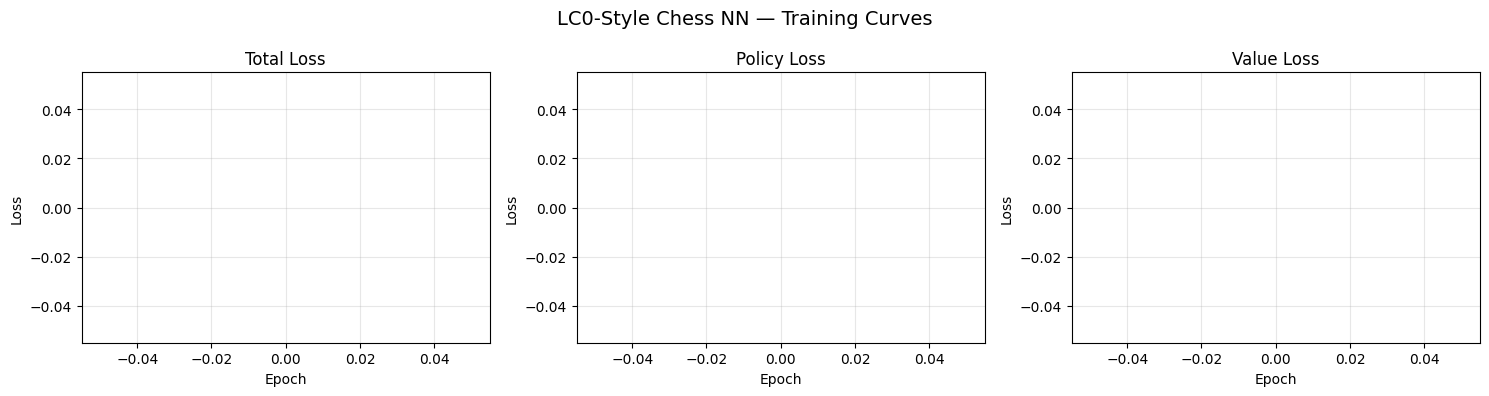

Training curves saved.


In [16]:
import matplotlib.pyplot as plt

epochs_range = list(range(1, len(history) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('LC0-Style Chess NN — Training Curves', fontsize=14)

for ax, key, title, color in [
    (axes[0], 'total',  'Total Loss',  'steelblue'),
    (axes[1], 'policy', 'Policy Loss', 'darkorange'),
    (axes[2], 'value',  'Value Loss',  'forestgreen'),
]:
    vals = [h[key] for h in history]
    ax.plot(epochs_range, vals, color=color, linewidth=2, marker='o', markersize=4)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Training curves saved.')

## 14. Chess Agent (Greedy Policy)

LC0Agent and RandomAgent defined.


## 15. Evaluation

In [17]:
def evaluate_vs_random(agent, n_games: int = 10):
    """Evaluate agent against random player. Returns win/draw/loss counts."""
    random_agent = RandomAgent()
    results      = {'win': 0, 'draw': 0, 'loss': 0}
    boards       = []

    for i in range(n_games):
        # Alternate colours
        if i % 2 == 0:
            board = play_game(agent, random_agent)
            result = board.result()
            if result == '1-0':   results['win']  += 1
            elif result == '0-1': results['loss'] += 1
            else:                 results['draw'] += 1
        else:
            board = play_game(random_agent, agent)
            result = board.result()
            if result == '0-1':   results['win']  += 1
            elif result == '1-0': results['loss'] += 1
            else:                 results['draw'] += 1
        boards.append(board)

    return results, boards


def evaluate_vs_stockfish(agent, n_games: int = 5,
                          skill_level: int = SF_EVAL_SKILL_LEVEL):
    """Evaluate agent against low-level Stockfish."""
    results = {'win': 0, 'draw': 0, 'loss': 0}
    boards  = []

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as sf_engine:
        sf_engine.configure({'Skill Level': skill_level})

        class SFAgent:
            def select_move(self, board):
                result = sf_engine.play(board, chess.engine.Limit(depth=1))
                return result.move

        sf_agent = SFAgent()

        for i in range(n_games):
            if i % 2 == 0:
                board  = play_game(agent, sf_agent)
                result = board.result()
                if result == '1-0':   results['win']  += 1
                elif result == '0-1': results['loss'] += 1
                else:                 results['draw'] += 1
            else:
                board  = play_game(sf_agent, agent)
                result = board.result()
                if result == '0-1':   results['win']  += 1
                elif result == '1-0': results['loss'] += 1
                else:                 results['draw'] += 1
            boards.append(board)

    return results, boards

print('Evaluation functions defined.')

Evaluation functions defined.


## 16. Run Evaluation

In [18]:
model.eval()
agent = LC0Agent(model, device=DEVICE, temperature=0.0)  # greedy for eval

# ── vs Random ──────────────────────────────────────────────
print(f'Evaluating vs Random ({EVAL_GAMES_VS_RANDOM} games)...')
r_results, r_boards = evaluate_vs_random(agent, n_games=EVAL_GAMES_VS_RANDOM)
print(f'  Results: W={r_results["win"]}  D={r_results["draw"]}  L={r_results["loss"]}')

pgn_vs_random = board_to_pgn(r_boards, white_name='LC0Net', black_name='Random')
with open('/content/games_vs_random.pgn', 'w') as f:
    f.write(pgn_vs_random)
print('  PGN saved → /content/games_vs_random.pgn')

# ── vs Stockfish ───────────────────────────────────────────
print(f'\nEvaluating vs Stockfish skill {SF_EVAL_SKILL_LEVEL} ({EVAL_GAMES_VS_SF} games)...')
try:
    sf_results, sf_boards = evaluate_vs_stockfish(
        agent, n_games=EVAL_GAMES_VS_SF, skill_level=SF_EVAL_SKILL_LEVEL
    )
    print(f'  Results: W={sf_results["win"]}  D={sf_results["draw"]}  L={sf_results["loss"]}')

    pgn_vs_sf = board_to_pgn(sf_boards, white_name='LC0Net', black_name='Stockfish')
    with open('/content/games_vs_stockfish.pgn', 'w') as f:
        f.write(pgn_vs_sf)
    print('  PGN saved → /content/games_vs_stockfish.pgn')
except Exception as e:
    print(f'  Stockfish evaluation failed: {e}')

print('\nEvaluation complete.')

Evaluating vs Random (10 games)...
  Results: W=0  D=8  L=2
  PGN saved → /content/games_vs_random.pgn

Evaluating vs Stockfish skill 0 (5 games)...
  Results: W=0  D=0  L=5
  PGN saved → /content/games_vs_stockfish.pgn

Evaluation complete.


## 17. Interactive Inference — Analyse a Position

In [19]:
@torch.no_grad()
def analyse_position(fen: str, top_k: int = 5):
    """
    Print the model's top-k policy moves and value estimate for a given FEN.
    """
    board  = chess.Board(fen)
    board_t = board_to_tensor(board).unsqueeze(0).to(DEVICE)
    mask    = legal_move_mask(board).unsqueeze(0).to(DEVICE)

    model.eval()
    logits, value = model(board_t)

    logits_masked = logits.masked_fill(~mask, -1e9)
    probs = F.softmax(logits_masked, dim=-1).squeeze(0).cpu().numpy()

    # Build (move, prob) pairs
    move_probs = []
    for move in board.legal_moves:
        try:
            idx = move_to_index(move, board)
            move_probs.append((move, probs[idx]))
        except Exception:
            pass

    move_probs.sort(key=lambda x: x[1], reverse=True)

    print(f'Position: {fen}')
    print(f'Value estimate: {value.item():.4f}  (positive = White better)')
    print(f'Top-{min(top_k, len(move_probs))} policy moves:')
    for move, prob in move_probs[:top_k]:
        print(f'  {move.uci():8s}  {prob*100:.2f}%')


# Example: starting position
analyse_position(chess.STARTING_FEN, top_k=5)
print()

# Example: open Sicilian position
sicilian_fen = 'rnbqkbnr/pp2pppp/3p4/2p5/3PP3/5N2/PPP2PPP/RNBQKB1R w KQkq - 0 4'
analyse_position(sicilian_fen, top_k=5)

Position: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Value estimate: -1.0000  (positive = White better)
Top-5 policy moves:
  c2c3      100.00%
  g1f3      0.00%
  e2e3      0.00%
  h2h3      0.00%
  d2d3      0.00%

Position: rnbqkbnr/pp2pppp/3p4/2p5/3PP3/5N2/PPP2PPP/RNBQKB1R w KQkq - 0 4
Value estimate: -1.0000  (positive = White better)
Top-5 policy moves:
  c2c3      100.00%
  d4d5      0.00%
  f3h4      0.00%
  f1a6      0.00%
  c1g5      0.00%


## 18. Summary & Next Steps

### What was built

| Component | Details |
|---|---|
| **Architecture** | LC0/AlphaZero-style residual CNN |
| **Blocks** | Configurable (default 15) residual blocks |
| **Channels** | Configurable (default 128) |
| **Input** | 17-plane AlphaZero board encoding |
| **Action space** | 4672 (64×73, AlphaZero encoding) |
| **Policy head** | 1×1 conv → flatten → FC, log-softmax with legal masking |
| **Value head** | 1×1 conv → flatten → FC → ReLU → FC → tanh |
| **Supervision** | Stockfish-generated policy + value targets |
| **Stability** | NaN detection, gradient clipping, logit clamping |
| **Evaluation** | vs Random + vs Stockfish, PGN export |

### Recommended next steps

1. **Scale up**: increase to 20 blocks / 256 channels with more training data
2. **Better data**: use real master game positions (e.g. Lichess database)
3. **MCTS**: add Monte-Carlo Tree Search for self-play RL fine-tuning
4. **Self-play RL**: once MCTS works, switch to AlphaZero-style RL loop
5. **Mixed precision**: use `torch.cuda.amp` for 2× speedup on A100/T4
6. **Opening book**: incorporate opening theory as prior
